# Create MT+Adaptation evaluation datasets 

In [ ]:
%load_ext autoreload
%autoreload 2

## Init

In [ ]:
# Standard Libraries
import base64
import difflib
import io
import json
import logging
import pprint
import random
import sys
import traceback
import urllib
from collections import Counter
from datetime import datetime
from logging.handlers import RotatingFileHandler
from pathlib import Path
from typing import Dict, List

# Other Libraries
import argilla as rg
import itables
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regex as re
import requests
import seaborn as sns
from bs4 import BeautifulSoup
import html2text
from datasets import (Dataset, DatasetDict, DatasetInfo, Features, Sequence,
                    Value, load_from_disk)
from dotenv import dotenv_values
from huggingface_hub import DatasetCard, DatasetCardData
from tabulate import tabulate
from tqdm import tqdm

#  Configuration & Constants
# Plotting and table display setup
sns.set_theme()
itables.init_notebook_mode(all_interactive=False)

# Constants
SPACE = " "
NL = "\n"

# Define the log file path
log_file = Path.home() / "logs" / f"{__name__}.log"


# Logging Setup
def setup_logger(log_file=log_file, max_bytes=10*1024*1024, backup_count=5):
    """
    Sets up a logger that logs INFO and above to stdout and everything to a
    rolling file.

    Args:
        log_file: The name of the log file (default: "out.log").
        max_bytes: The maximum size of the log file before it rolls over
            (default: 10MB).
        backup_count: The number of backup log files to keep (default: 5).
    """
    # Create a logger
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()  # Clear existing handlers

    # Create a formatter
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s [%(name)s:%(lineno)d]')

    # --- Path Check & File Handler Setup ---
    try:
        # Ensure the log directory exists
        log_dir = Path(log_file).parent
        log_dir.mkdir(parents=True, exist_ok=True)
        
        # Create a rolling file handler (all levels)
        file_handler = RotatingFileHandler(log_file,
                                           maxBytes=max_bytes,
                                           backupCount=backup_count)
        file_handler.setLevel(logging.DEBUG)  # Log all levels to the file
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)
        
    except (OSError, FileNotFoundError) as e:
        # Report error if log directory or file cannot be created
        print(f"Error: Could not create log file at {log_file}. Logging to file will be disabled. Error: {e}", file=sys.stderr)
    except Exception as e:
        # Catch any other unexpected errors
        print(f"An unexpected error occurred during log file setup: {e}", file=sys.stderr)
    # --- End Path Check ---

    # Create a handler for stdout (INFO and above)
    stdout_handler = logging.StreamHandler(sys.stdout)
    stdout_handler.setLevel(logging.INFO)
    stdout_handler.setFormatter(formatter)
    
    # Add the stdout handler
    logger.addHandler(stdout_handler)

    return logger

# Initialization
# Load environment variables
env = dotenv_values()
print(f"Loaded environment variables: {list(env.keys())}")

# Setup the logger
logger = setup_logger()
logger.info("Finished initializing environment.")


## Import json to dataframe


In [ ]:
def clean_html(html_text: str) -> str:
    """
    Converts HTML to a clean, readable plain-text representation,
    respecting paragraphs, breaks, and lists.
    
    Args:
        html_text: A string containing HTML content.
        
    Returns:
        A plain-text string with formatting preserved.
    """
    if not isinstance(html_text, str):
        return ""

    # Initialize the converter
    h = html2text.HTML2Text()
    
    # Configure it to your needs (optional)
    h.ignore_links = True     # Don't show links as [text](url)
    h.ignore_images = True  # Don't show image placeholders
    h.body_width = 0          # Don't wrap lines

    # Handle the HTML
    text = h.handle(html_text)
    
    return text.strip()


def print_structure(data, indent=0):
    """
    Recursively prints the structure of a JSON object or array.
    
    - For objects (dicts), it prints each key and the type of its value.
    - For arrays (lists), it inspects the first element to show the
      structure of items in the list.
    - For primitive values, it just prints the type.
    """
    # Create an indentation string
    indent_str = "  " * indent
    
    if isinstance(data, dict):
        # It's an object, iterate through its keys
        print(f"{indent_str}{{ (object) }}")
        for key, value in data.items():
            print(f"{indent_str}  '{key}': ", end="")
            
            if isinstance(value, dict):
                # Value is a nested object
                print_structure(value, indent + 2)
            elif isinstance(value, list):
                # Value is a nested list/array
                print_structure(value, indent + 2)
            else:
                # Value is a primitive (str, int, bool, None)
                print(f"<{type(value).__name__}>")
                
    elif isinstance(data, list):
        # It's an array, inspect the first element (if it exists)
        if len(data) > 0:
            print(f"[ (array of...) ]")
            # Recurse on the first item to show the structure of list elements
            print_structure(data[0], indent + 1)
        else:
            print(f"[ (empty array) ]")
            
    else:
        # It's a standalone primitive (e.g., the whole JSON is just "hello")
        print(f"{indent_str}<{type(data).__name__}>")


dev_merged = "../data/mt_and_adaptation/dev_merged.json"
try:
    with open(dev_merged, 'r') as f:
        file_data = json.load(f)
        logging.info("--- Input Structure ---")
        print_structure(file_data)
except FileNotFoundError:
    logging.info("file not found.")
except json.JSONDecodeError as e:
    logging.info(f"Error decoding JSON from file: {e}")

In [ ]:
# Open and load the JSON file into a dictionary
with open("../data/mt_and_adaptation/dev_merged.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
    df = pd.DataFrame(data)
    df.rename(columns={"final": "final_gt"}, inplace=True)



### Examine dataset

In [ ]:

display(df)

## Prepare Argilla 

### Users and workspace

In [ ]:
client = rg.Argilla(
    api_url=env["ARGILLA_API_URL"],
    api_key=env["ARGILLA_API_KEY"]
)

recreate = False
workspaces = client.workspaces
if recreate:    
    try:
        user_to_create = rg.User(
            username="soksof",
            password="FIXME",
            )
        created_user = user_to_create.create()
    except:
        traceback.print()
        pass
    user_to_update = client.users('soksof')
    user_to_update.first_name = 'Sokratis'
    user_to_update.last_name = 'Sofianopoulos'
    user_to_update.role = 'admin'
    updated_user = user_to_update.update()    

recreate = False
workspaces = client.workspaces
if recreate:    
    workspaces_to_create = [
        {"name":"media2day", "users_to_add":["prokopis", "pkyriazi", "soksof" ]}]
    for workspace_to_create in workspaces_to_create:
        try:
            created_workspace = rg.Workspace(name=workspace_to_create["name"]).create()
            #logger.debug(created_workspace)
        except:
            traceback.print_exc()            
        for user_to_add in workspace_to_create["users_to_add"]:
            user_to_add = client.users(user_to_add)
            try: 
                #logger.debug(user_to_add)
                user_to_add.add_to_workspace(client.workspaces(workspace_to_create["name"]))
                #added_user = rg.Workspace(name=workspace_to_create["name"]).add_user(user_to_add)
            except:
                pass

    for workspace in workspaces:    
        for user in workspace.users:
            pass
            #logger.info(f"Workspace: {workspace.name}, User:{user.username}, UserId:{user.id}")



## Create the Argilla datasets

### MT evaluation

In [1]:
guidelines = """# Guidelines

## MT Evaluation

### Accuracy and Adequacy

Evaluate whether the translation accurately conveys the full meaning of the source text, without adding, omitting, or distorting information.

Compare the translation to the original text sentence by sentence, or segment by segment, to check for semantic equivalence.

### Fluency and Grammaticality

Evaluate the quality of the output text, i.e. whether the output sounds like a natural, well-written text, independent of the source text.

This includes grammaticality, spelling, punctuation, word choice (idiomaticity), and natural flow.

### Cohesion and Consistency

Cohesion: Are the sentences and paragraphs logically connected? Evaluate the use of linguistic devices (like conjunctions, pronouns, and synonyms) to link sentences together, ensuring the text flows smoothly from one idea to the next.

Consistency: Is the same terminology and style used throughout the document?
Evaluate the uniform use of specific terms and stylistic choices. This is crucial for technical manuals, legal documents, and branded content.

-----------------------------------
## Adaptation

How well is the final, adapted document suited for its intended purpose and target audience?

Check for:

- Utility and Accuracy of Additions. Are any added, possibly introductory paragraphs (e.g., "Σε ένα άρθρο που δημοσιεύτηκε στις 10 Ιουνίου, ...") helpful, relevant, and natural for the user? Does any source attribution at the end meet transparency or a specific style requirement? Is any new content introduced factually correct? Does any final source citation ("xyz.com") point to the actual source of the content?

- Effectiveness of Reductions. In the case of any summarization or reduction of content, did the adaptation model successfully remove content that was "not particularly useful"? Or did it incorrectly remove essential information, making the document less useful or misleading?


---

## 5-Point Likert Scale for Evaluation

| Criterion | **1: Very Poor** | **2: Poor** | **3: Passable** | **4: Good** | **5: Perfect** |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Accuracy / Adequacy** | Most meaning is lost, distorted, or omitted. | Major omissions, additions, or distortions of meaning. | Preserves the main idea, but with several inaccuracies or omissions. | Accurately conveys most meaning; only minor omissions or distortions. | Perfectly conveys the full meaning. No additions, omissions, or distortions. |
| **Fluency / Grammaticality** | Incomprehensible. Severe errors in grammar, spelling, punctuation, and word choice. | Disfluent. Hard to read; many errors in grammar, spelling, or word choice. | Understandable, but has awkward phrasing, unnatural word choice, or several errors. | Fluent and easy to read; only minor, occasional errors in grammar or word choice. | Flawless. Sounds perfectly natural (grammar, spelling, punctuation, idiomaticity). |
| **Cohesion / Consistency** | Incoherent and contradictory. No logical flow; highly inconsistent terminology and style. | Poorly connected. Hard to follow; significant inconsistencies in terms or style. | Mostly flows, but with some abrupt transitions; some noticeable inconsistencies. | Well-connected and easy to follow; terminology and style are mostly consistent. | Perfect. Flows logically from start to finish; completely consistent terminology and style. |
| **Adaptation** | Detrimental. Additions are incorrect/irrelevant. Reductions remove essential info. Document is unfit for purpose. | Poor. Additions are unhelpful or unnatural. Reductions are clumsy and remove useful info. | Passable. Additions/reductions are mediocre; they don't harm the document but don't help much. | Good. Additions (intros, citations) are helpful and mostly correct. Reductions successfully remove non-essential content. | Perfect. All additions are relevant, helpful, accurate, and natural. All reductions skillfully remove *only* non-useful info. |


"""

In [ ]:
css_template = """
<div id="docs_content"></div>
<script id="docs_template" type="text/x-handlebars-template">
    <style>
    #container {
        display: flex;
        gap: 10px;
    }
    .column {
        flex: 1;
    }
    /* --- Added color rules --- */
    .column:nth-child(1) h3 {
        color: #4A90E2; /* Blue */
    }
    .column:nth-child(2) h3 {
        color: #2ECC71; /* Green */
    }
    .column:nth-child(3) h3 {
        color: #F39C12; /* Orange */
    }
    .column:nth-child(4) h3 {
        color: #9B59B6; /* Purple */
    }    
    </style>
    <div id="container">
        <div class="column">
            <h3>Source document</h3>
            <div>{{{record.fields.docs.source_doc}}}</div>
        </div>
        <div class="column">
            <h3>Ground truth</h3>
            <div>{{{record.fields.docs.ground_truth_doc}}}</div>
        </div>
        <div class="column">
            <h3>MT</h3>
            <div>{{{record.fields.docs.mt_doc}}}</div>
        </div>
        <div class="column">
            <h3>MT + Adaptation</h3>
            <div>{{{record.fields.docs.mt_adapt_doc}}}</div>
        </div>
    </div>
</script>    
""" # 


script = """
<script src="https://cdn.jsdelivr.net/npm/handlebars@latest/dist/handlebars.js"></script>
<script>
    const docs_template = document.getElementById("docs_template").innerHTML;
    const compiledTemplate = Handlebars.compile(docs_template);
    const html = compiledTemplate({ record });
    document.getElementById("docs_content").innerHTML = html;
</script>
""" #

recreate = False
dataset_name = "media2day_mt"
workspace_name = "media2day"
min_submitted = 2
# initial	translated	final	final_gt
if recreate:
    settings = rg.Settings(
        guidelines=guidelines,
        fields=[
            rg.CustomField(
                name="docs",
                template=css_template + script,
                advanced_mode=True
            ),
            rg.TextField(
                name="id_field",
                title="ID",
            )
        ],
        distribution=rg.TaskDistribution(min_submitted=min_submitted),
        metadata=[
           rg.TermsMetadataProperty(
                name="id_meta",                
                title="ID",
                visible_for_annotators=True,
            )
        ],
        questions=[
           rg. RatingQuestion (
                name="accuracy_adequacy",                
                title="Accuracy and Adequacy",
                values=[1, 2, 3, 4, 5],
            ),
           rg.RatingQuestion(
                name="fluency_and_grammaticality",                
                title="Fluency and Grammaticality",
                values=[1, 2, 3, 4, 5],
            ),
           rg.RatingQuestion(
                name="cohesion_and_consistency",                
                title="Cohesion and Consistency",
                values=[1, 2, 3, 4, 5],
            ),
           rg.RatingQuestion(
                name="adaptation",                
                title="Adaptation",
                values=[1, 2, 3, 4, 5],
            ),
        ],
    )
    
    dataset = rg.Dataset(
        name=dataset_name,
        workspace=workspace_name, 
        settings=settings,
        client=client,
    )
    
    for cdataset in client.datasets:
        if cdataset.name==dataset_name:
            cdataset.delete()
    dataset.create()


In [ ]:

recreate =  False
records = list()
if recreate:
    for idx, row in  tqdm(df.iterrows(), total=df.shape[0]):
        try:
            record = rg.Record(
                fields = {
                            "docs": {
                                "source_doc": f'{row["initial"]}',
                                "mt_doc": row["translated_krikri-dpo-context"],                    
                                "mt_adapt_doc": row["final_krikri-dpo-context"],
                                "ground_truth_doc": row["final_gt"],
                            },
                            "id_field": str( row["id"]),
                    },
                metadata = {
                        "id_meta": row["id"],
                },
            )
            records.append(record)
        except:
            logger.info( f'Id: {row["id"]} ' )
            traceback.print_exc()
            break
        # if idx==100000:
        #     break
        # print(json.dumps(doc_results, ensure_ascii=False, indent=2))

    if records:
        status_filter = rg.Query(
            filter = rg.Filter(("response.status", "==", "pending"))
        )
        # logger.info(records)
        try:
            try:
                records_to_delete = list(dataset.records(status_filter))
                dataset.records.delete(records_to_delete)
            except:
                pass
            dataset.records.log(records)
        except:
            traceback.print_exc()
            pass


## MT + Adaptation dataset

In [ ]:
css_template = """
<div id="docs_content"></div>
<script id="docs_template" type="text/x-handlebars-template">
    <style>
    #container {
        display: flex;
        gap: 10px;
    }
    .column {
        flex: 1;
    }
    /* --- Added color rules --- */
    .column:nth-child(1) h3 {
        color: #4A90E2; /* Blue */
    }
    .column:nth-child(2) h3 {
        color: #2ECC71; /* Green */
    }
    .column:nth-child(3) h3 {
        color: #F39C12; /* Orange */
    }
    .column:nth-child(4) h3 {
        color: #9B59B6; /* Purple */
    }    
    </style>
    <div id="container">
        <div class="column">
            <h3>Source document</h3>
            <div>{{{record.fields.docs.source_doc}}}</div>
        </div>
        <div class="column">
            <h3>Ground truth</h3>
            <div>{{{record.fields.docs.ground_truth_doc}}}</div>
        </div>
        <div class="column">
            <h3>LLM A</h3>
            <div>{{{record.fields.docs.llm_1_doc}}}</div>
        </div>
        <div class="column">
            <h3>LLM B</h3>
            <div>{{{record.fields.docs.llm_2_doc}}}</div>
        </div>

    </div>
</script>    
""" 



script = """
<script src="https://cdn.jsdelivr.net/npm/handlebars@latest/dist/handlebars.js"></script>
<script>
    const docs_template = document.getElementById("docs_template").innerHTML;
    const compiledTemplate = Handlebars.compile(docs_template);
    const html = compiledTemplate({ record });
    document.getElementById("docs_content").innerHTML = html;
</script>
""" #

recreate = False
dataset_name = "media2day_comparison"
workspace_name = "media2day"
guidelines =  "This task consists in blindly evaluating the output of two models for the task of MT and adaptation of greek news articles. The output of each model appears randomly as LLM (A) and LLM (B)."
min_submitted = 2
# initial	translated	final	final_gt
if recreate:
    settings = rg.Settings(
        guidelines=guidelines,
        fields=[
            rg.CustomField(
                name="docs",
                template=css_template + script,
                advanced_mode=True
            ),
            rg.TextField(
                name="id_field",
                title="ID",
            )
        ],
        distribution=rg.TaskDistribution(min_submitted=min_submitted),
        metadata=[
           rg.TermsMetadataProperty(
                name="id_meta",                
                title="ID",
                visible_for_annotators=True,
            ),
            rg.TermsMetadataProperty(
                name="llm_output_1_name",                
                title="llm_output_1_name",
                visible_for_annotators=False,
            ),
            rg.TermsMetadataProperty(
                name="llm_output_2_name",                
                title="llm_output_2_name",
                visible_for_annotators=False,
            )            
        ],
        questions = [
            rg.LabelQuestion(name="label_response", labels=["A is better", "B is better", "Both are ok", "Both are bad"])
        ],

    )
    
    dataset = rg.Dataset(
        name=dataset_name,
        workspace=workspace_name, 
        settings=settings,
        client=client,
    )
    
    for cdataset in client.datasets:
        if cdataset.name==dataset_name:
            cdataset.delete()
    dataset.create()


recreate =  False
records = list()
if recreate:
    # Define the names of the large language models
    llm_1_name = "final_krikri-dpo-context"
    llm_2_name = "final_gemma3-27b-it"
    # A list of model names to choose from
    model_choices = [llm_1_name, llm_2_name]
    
    for idx, row in  tqdm(df.iterrows(), total=df.shape[0]):
        shuffled_choices = model_choices.copy()
        random.shuffle(shuffled_choices)        
        llm_1_doc = row[shuffled_choices[0]]
        llm_2_doc = row[shuffled_choices[1]]

        try:
            record = rg.Record(
                fields = {
                            "docs": {
                                "source_doc": f'{row["initial"]}',
                                "ground_truth_doc": row["final_gt"],
                                "llm_1_doc": llm_1_doc,                    
                                "llm_2_doc": llm_2_doc,
                            },
                            "id_field": str( row["id"]),
                    },
                metadata = {
                        "id_meta": row["id"],
                        "llm_output_1_name": shuffled_choices[0],
                        "llm_output_2_name": shuffled_choices[1],
                },
            )
            records.append(record)
        except:
            logger.info( f'Id: {row["id"]} ' )
            traceback.print_exc()
            break

    if records:
        status_filter = rg.Query(
            filter = rg.Filter(("response.status", "==", "pending"))
        )
        # logger.info(records)
        try:
            try:
                records_to_delete = list(dataset.records(status_filter))
                dataset.records.delete(records_to_delete)
            except:
                pass
            dataset.records.log(records)
        except:
            traceback.print_exc()
            pass


## Extract Argilla datasets

In [ ]:
client = rg.Argilla(
    api_url=env["ARGILLA_API_URL"],
    api_key=env["ARGILLA_API_KEY"]
)

workspaces = client.workspaces


### MT + Adaptation dataset

In [ ]:
# 0. Define the dataset
 
dataset = client.datasets(name="media2day_comparison", workspace="media2day")
records = list(dataset.records())

# 1. Flatten data immediately during ingestion
df_records = list()

for record in records:
    # Clean names once here (string manipulation is cheaper on single strings than whole columns later)
    model_a = record.metadata["llm_output_1_name"].replace('final_', '')
    model_b = record.metadata["llm_output_2_name"].replace('final_', '')
    
    # Iterate through responses here to avoid using .explode() later
    for resp in record.responses["label_response"]:
        df_record = {
            "idx": record.fields["id_field"],
            "user_id": resp.user_id,
            "judgment": resp.value,
            "llm_1_doc": record.fields["docs"]["llm_1_doc"],
            "llm_2_doc": record.fields["docs"]["llm_2_doc"],
            "llm_output_1_name": model_a,
            "llm_output_2_name": model_b,
        }
        df_records.append(df_record)

df = pd.DataFrame(df_records)

# 2. Vectorized 'Winner' Logic
# Instead of .apply(axis=1) which loops row-by-row, use numpy.select for speed
conditions = [
    df['judgment'] == 'A is better',
    df['judgment'] == 'B is better'
]
choices = [
    df['llm_output_1_name'],
    df['llm_output_2_name']
]
# If neither condition is met, default to the judgment string (e.g., "Both are bad")
df['answer'] = np.select(conditions, choices, default=df['judgment'])

# 3. Aggregation and Plotting
categories = ["gemma3-27b-it", "krikri-dpo-context", 'Both are ok', 'Both are bad']

# value_counts + reindex handles the loop and missing categories automatically
plot_data = df['answer'].value_counts().reindex(categories, fill_value=0)

# Sort strictly descending as per your previous logic
plot_data = plot_data.sort_values(ascending=False)


answer,Both are bad,Both are ok,gemma3-27b-it,krikri-dpo-context,Total Answers
user_id,,,,,
09ecad5d-ae67-4b07-a722-0b61e56391df,12,25,52,11,100


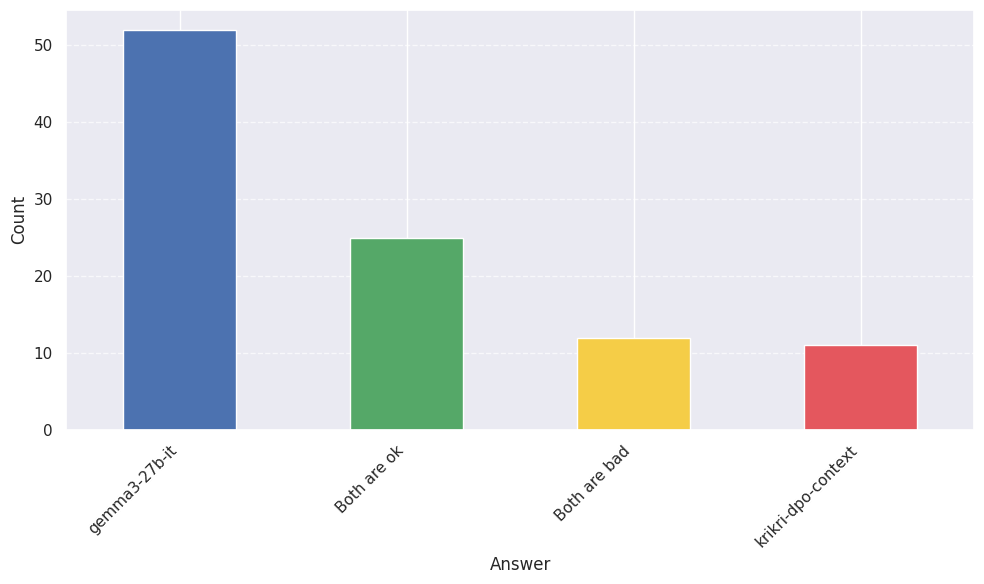

In [52]:
# 4. Visualize
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color=['#4C72B0', '#55A868', '#F5CD47', '#E4575E'])
plt.xlabel('Answer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_and_tie_counts.png')

# 5. Statistics Table
user_stats = pd.crosstab(
    df['user_id'], 
    df['answer'], 
    normalize=False 
)
user_stats['Total Answers'] = user_stats.sum(axis=1)

display(user_stats)